# Healthcare Disease Risk Prediction

This notebook covers a simple, clear workflow for predicting disease risk using patient data.

**Dataset includes:** Patient records, Age, BMI, Blood Pressure, Disease History, Lifestyle Data.

**Tasks:**

1. Handle missing and inconsistent medical data.
2. Perform feature selection based on correlation.
3. Build a classification model to predict disease risk.
4. Evaluate using Precision, Recall, F1 Score.
5. Explain ethical concerns in healthcare AI.


In [82]:
# 1. Load and Explore Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('datas/heart_disease_health_indicators_BRFSS2015.csv')
print('Shape:', df.shape)
display(df.head())
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isnull().sum())

Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Columns: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Missing values per column:
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [83]:
# 2. Handle Missing and Inconsistent Data
# Replace 0s in key columns with the mean (if 0 is not a valid value)
columns_to_fix = [col for col in ['BMI','BloodPressure','Age'] if col in df.columns]
for col in columns_to_fix:
    mean_val = df[df[col] != 0][col].mean()
    df[col] = df[col].replace(0, mean_val)
    print(f'Replaced zeros in {col} with mean:', mean_val)

# Fill any remaining missing values with column mean
df.fillna(df.mean(), inplace=True)
print('Any missing values left?')
print(df.isnull().sum().sum() == 0)

Replaced zeros in BMI with mean: 28.382363607694735
Replaced zeros in Age with mean: 8.032119205298013
Any missing values left?
True


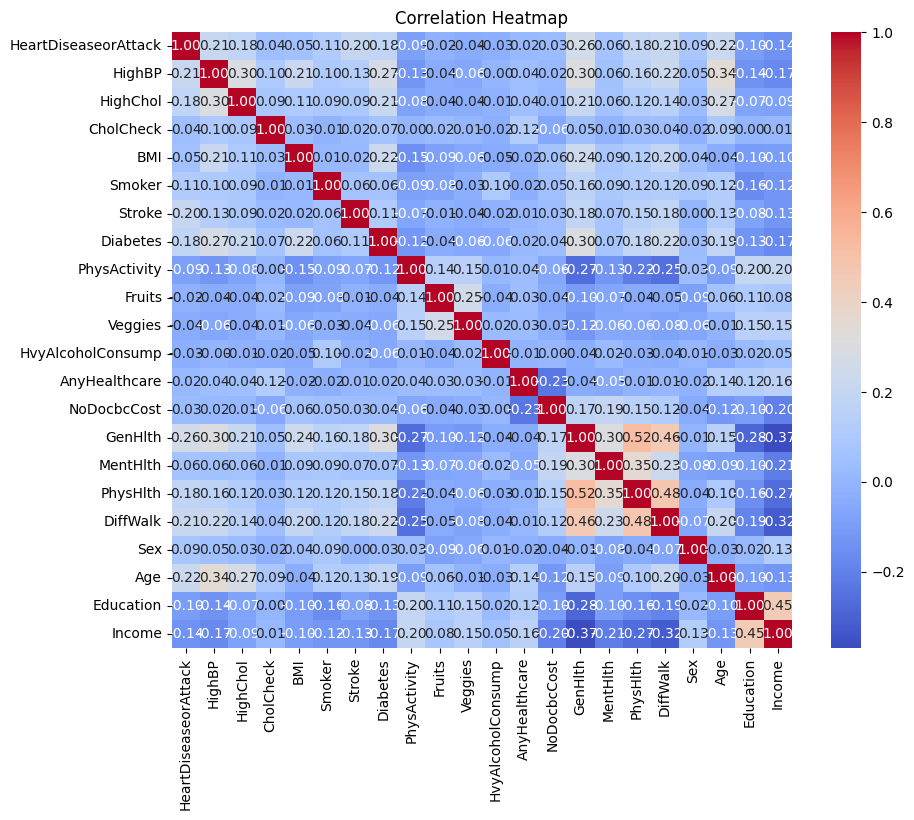

Correlation with target:
HeartDiseaseorAttack    1.000000
GenHlth                 0.258383
Age                     0.221618
DiffWalk                0.212709
HighBP                  0.209361
Stroke                  0.203002
PhysHlth                0.181698
HighChol                0.180765
Diabetes                0.180272
Smoker                  0.114441
Sex                     0.086096
MentHlth                0.064621
BMI                     0.052904
CholCheck               0.044206
NoDocbcCost             0.031000
AnyHealthcare           0.018734
Fruits                 -0.019790
HvyAlcoholConsump      -0.028991
Veggies                -0.039167
PhysActivity           -0.087299
Education              -0.099600
Income                 -0.141011
Name: HeartDiseaseorAttack, dtype: float64


In [84]:
# 3. Feature Selection Based on Correlation
# Calculate correlation matrix and show heatmap
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# Print features most correlated with the target column
if 'HeartDiseaseorAttack' in df.columns:
    print('Correlation with target:')
    print(corr['HeartDiseaseorAttack'].sort_values(ascending=False))

In [85]:
# 4. Build a Classification Model to Predict Disease Risk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Select features (drop target and any non-numeric columns)
if 'HeartDiseaseorAttack' in df.columns:
    X = df.drop(['HeartDiseaseorAttack'], axis=1).select_dtypes(include='number')
    y = df['HeartDiseaseorAttack']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('Model trained and predictions made.')

Model trained and predictions made.


              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     45968
         1.0       0.55      0.13      0.21      4768

    accuracy                           0.91     50736
   macro avg       0.73      0.56      0.58     50736
weighted avg       0.88      0.91      0.88     50736



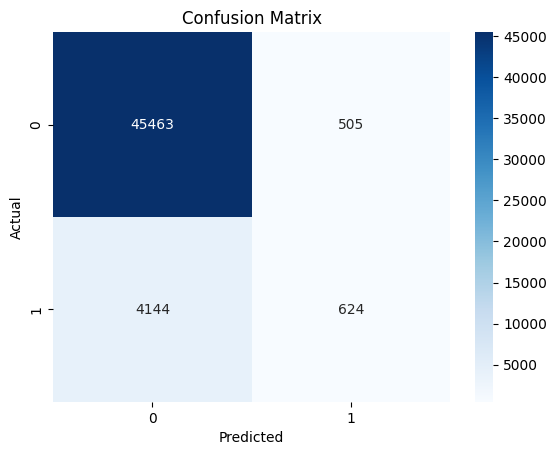

In [86]:
# 5. Evaluate the Model: Precision, Recall, F1 Score
from sklearn.metrics import classification_report, confusion_matrix
if 'HeartDiseaseorAttack' in df.columns:
    print(classification_report(y_test, y_pred))
    # Confusion matrix visualization
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

## 6. Ethical Concerns in Healthcare AI

1. **Bias in Data:** If the data is not balanced or has errors, the model might make unfair predictions for some groups.
2. **Wrong Predictions:** If the model makes a mistake, it could affect a patient's health or treatment.
3. **Privacy:** Medical records are private. Using them in AI needs to be very careful to protect people's information.
